# Influencer Impact Analysis

## Project Overview

This project investigates how the sentiment of tweets posted by social media influencers affects 
the engagement they receive from their followers. Specifically, it asks: do negative tweets 
generate more audience response than positive ones, and does this pattern hold consistently 
across influencers of different sizes and domains?

## Dataset

- **40 influencers** across categories including music, politics, sports, and entertainment
- Tweets collected via the Twitter API for each influencer
- Each tweet contains: tweet ID, timestamp, favourite count, retweet count, and text
- Combined dataset of approximately 50,000 tweets

## Methodology

1. **Data cleaning** — URLs, mentions, hashtags, emojis and non-alphabetic characters removed from tweet text
2. **Sentiment classification** — Each tweet scored using NLTK's Opinion Lexicon, a curated dictionary of positive and negative English words. Tweets scoring below 0 are classified as negative; all others (including neutral) as positive
3. **Engagement normalisation** — Rather than using raw engagement numbers (which vary with follower size), each influencer's positive and negative averages are expressed as a ratio relative to their own overall average. A ratio above 1.0 means that sentiment type performs above that influencer's average
4. **Aggregation** — Normalised ratios for all 40 influencers are collected into a single output file and analysed collectively

## Key Finding

Across all 40 influencers analysed, negative content consistently generates higher engagement 
than positive content, with an average of approximately **25% more engagement** 
(14% more favourites and 28% more retweets). This pattern holds regardless of influencer size 
or domain, suggesting it is a structural property of how audiences respond to sentiment on Twitter.

## Tools Used

Python, Pandas, NumPy, NLTK, Matplotlib, Google Colab

<b> Importing the necessary libraries </b>

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import nltk
import csv
nltk.download('opinion_lexicon')
from nltk.corpus import opinion_lexicon

[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     C:\Users\LANOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!


In [79]:
import os

# Clear previous Output.csv
if os.path.exists('Output.csv'):
    os.remove('Output.csv')

# Map each file to display name
influencer_list = [
    ('ArianaGrande_tweets.csv', 'Ariana Grande'),
    ('BarackObama_tweets.csv', 'Barack Obama'),
    ('BillGates_tweets.csv', 'Bill Gates'),
    ('britneyspears_tweets.csv', 'Britney Spears'),
    ('BrunoMars_tweets.csv', 'Bruno Mars'),
    ('ddlovato_tweets.csv', 'Demi Lovato'),
    ('Drake_tweets.csv', 'Drake'),
    ('elonmusk_tweets.csv', 'Elon Musk'),
    ('Eminem_tweets.csv', 'Eminem'),
    ('Harry_Styles_tweets.csv', 'Harry Styles'),
    ('HillaryClinton_tweets.csv', 'Hillary Clinton'),
    ('JenniferAnnistn_tweets.csv', 'Jennifer Aniston'),
    ('jimmyfallon_tweets.csv', 'Jimmy Fallon'),
    ('JLo_tweets.csv', 'Jennifer Lopez'),
    ('JoeBiden_tweets.csv', 'Joe Biden'),
    ('jtimberlake_tweets.csv', 'Justin Timberlake'),
    ('justinbieber_tweets.csv', 'Justin Bieber'),
    ('KamalaHarris_tweets.csv', 'Kamala Harris'),
    ('kanyewest_tweets.csv', 'Kanye West'),
    ('katyperry_tweets.csv', 'Katy Perry'),
    ('KevinHart4real_tweets.csv', 'Kevin Hart'),
    ('KimKardashian_tweets.csv', 'Kim Kardashian'),
    ('KingJames_tweets.csv', 'LeBron James'),
    ('KylieJenner_tweets.csv', 'Kylie Jenner'),
    ('ladygaga_tweets.csv', 'Lady Gaga'),
    ('LiamPayne_tweets.csv', 'Liam Payne'),
    ('Louis_Tomlinson_tweets.csv', 'Louis Tomlinson'),
    ('maddow_tweets.csv', 'Rachel Maddow'),
    ('MileyCyrus_tweets.csv', 'Miley Cyrus'),
    ('neymarjr_tweets.csv', 'Neymar Jr'),
    ('NiallOfficial_tweets.csv', 'Niall Horan'),
    ('Oprah_tweets.csv', 'Oprah Winfrey'),
    ('realDonaldTrump_tweets.csv', 'Donald Trump'),
    ('rickygervais_tweets.csv', 'Ricky Gervais'),
    ('rihanna_tweets.csv', 'Rihanna'),
    ('selenagomez_tweets.csv', 'Selena Gomez'),
    ('shakira_tweets.csv', 'Shakira'),
    ('taylorswift13_tweets.csv', 'Taylor Swift'),
    ('TheEllenShow_tweets.csv', 'Ellen DeGeneres'),
    ('zaynmalik_tweets.csv', 'Zayn Malik'),
]

<b> Importing the Dataset </b>

In [80]:
dataset = pd.read_csv(f'Tweets data/zaynmalik_tweets.csv')
influencer_name = 'Zayn Malik'

<b> Converting the Text column to string </b>

In [81]:
dataset['text']=dataset['text'].apply(str)

<b> Displaying the first 50 rows of the dataset </b>

In [82]:
dataset.head(50)

,id,created_at,favorite_count,retweet_count,text
0,1.320110e+18,24-10-2020 20:55,139790,28218,@UFC mashallah Khabib 🙌🏽
1,1.317670e+18,18-10-2020 03:29,569129,87992,Vote.
2,1.317150e+18,16-10-2020 17:15,233048,21761,Mad respect 👊🏽 https://t.co/N4WOgPVqEY
3,1.314300e+18,08-10-2020 20:05,225031,27121,Buzzin off this set 😎🔥 bangers \n\nhttps://t.c...
4,1.312610e+18,04-10-2020 04:40,306080,30116,Ohhhh sheeeet preachers daughter all day 🔥 .@...
5,1.310070e+18,27-09-2020 04:20,47995,9341,@ufc #UFC253 go on Israel show the world 👊🏽
6,1.309640e+18,25-09-2020 23:30,328838,59464,#better Out Now 🤘🏽\nhttps://t.co/mOJAuVlmYF ht...
7,1.309350e+18,25-09-2020 04:46,345337,70848,https://t.co/mOJAuVlmYF https://t.co/lTeg4SJpMG
8,1.309130e+18,24-09-2020 14:04,382876,68564,#better https://t.co/mOJAuVlmYF https://t.co/i...
9,1.308950e+18,24-09-2020 01:51,2202883,567742,"Our baby girl is here, healthy &amp; beautiful..."


<h2> Cleansing the text </h2>

In [83]:
corpus = []
n = 2788
for i in range(0,n):
  review = dataset['text'][i]
  review = re.sub(r"(?:\@|https?\://)\S+","", review) # Removing URLS and links as well as user mentions #
  review = re.sub(r"(?:\#)\S+","", review)            # Removing Hashtags #
  review = re.sub('[^a-zA-Z]', ' ', review)           # Removing non alphabetic characters such as emojis and punctuations #
  review = review.lower()                             # Converting to lowercase #
  review = review.split()
  review = ' '.join(review)
  corpus.append(review)

<h3> Displaying the cleansed texts </h3> 

In [84]:
print(corpus[0:50])

['mashallah khabib', 'vote', 'mad respect', 'buzzin off this set bangers', 'ohhhh sheeeet preachers daughter all day', 'go on israel show the world', 'out now', '', '', 'our baby girl is here healthy amp beautiful to try put into words how i am feeling right now would be an impossible task the love i feel for this tiny human is beyond my understanding grateful to know her proud to call her mine amp thankful for the life we will have together x', '', 'the new game is sick check it out', 'what a card throwing hefty ones tonight', '', 'play against my squad in fifa featured squad battles now', 'cmon cormier', '', '', '', 'ferguson trained for khabib and still put on that crazy display last night what a veteran enough respect', 'vote for for at the by rt ing or head to', 'proud to be a brit what a fight incredible night', 'yo thank you so much for letting me know about this i do not have any new collaborations coming so please just keep checking here for any news you know you will always b

<b> Importing the list of Positive and Negative words for classification </b>

In [85]:
pos_list=set(opinion_lexicon.positive())
neg_list=set(opinion_lexicon.negative())

<b> Importing the tokenizer for tokenizing in the Sentiment function </b>

In [86]:
from nltk.tokenize import treebank
tokenizer = treebank.TreebankWordTokenizer()

<h2> Defining the Sentiment function </h2>

In [87]:
def sentiment(sentence):
  senti=0
  words = [word.lower() for word in tokenizer.tokenize(sentence)]
  for word in words:
    if word in pos_list:
      senti += 1           #If word is positive, incrementing the value of positive sentiment #
    elif word in neg_list:
      senti -= 1            #If word is negative, incrementing the value of negative sentiment #
  return senti

<b> Converting the cleansed text into array </b>

In [88]:
corpus = np.asarray(corpus)
dataset['text'] = corpus

<b> Applying the sentiment function to the dataset </b>

In [89]:
dataset['sentiment']=dataset['text'].apply(sentiment)

<b> Displaying the cleansed dataset with the sentiment column </b>

In [90]:
dataset.head(50)

,id,created_at,favorite_count,retweet_count,text,sentiment
0,1.320110e+18,24-10-2020 20:55,139790,28218,mashallah khabib,0
1,1.317670e+18,18-10-2020 03:29,569129,87992,vote,0
2,1.317150e+18,16-10-2020 17:15,233048,21761,mad respect,0
3,1.314300e+18,08-10-2020 20:05,225031,27121,buzzin off this set bangers,0
4,1.312610e+18,04-10-2020 04:40,306080,30116,ohhhh sheeeet preachers daughter all day,0
5,1.310070e+18,27-09-2020 04:20,47995,9341,go on israel show the world,0
6,1.309640e+18,25-09-2020 23:30,328838,59464,out now,0
7,1.309350e+18,25-09-2020 04:46,345337,70848,,0
8,1.309130e+18,24-09-2020 14:04,382876,68564,,0
9,1.308950e+18,24-09-2020 01:51,2202883,567742,our baby girl is here healthy amp beautiful to...,6


<b> Note:  For analysis purpose, neutral opinion is considered as positive </b>

In [91]:
fav_count_avg = dataset["favorite_count"].mean()           # Overall avg of fav count #
retweet_count_avg = dataset["retweet_count"].mean()        # Overall avg of retweets #
print("The average fav count is: " ,fav_count_avg, " and the avg retweet count is:" ,retweet_count_avg)

The average fav count is:  54988.956241032996  and the avg retweet count is: 33479.062410329985


<h2> Calculating the averages for positive and negative sentiments </h2>

In [92]:
pos = 0 
neg = 0
p_fc =0
p_rt = 0 
n_fc = 0
n_rt =0
for i in range(0,n):
    if(dataset['sentiment'][i]<0):
        neg+=1
        n_fc+=dataset['favorite_count'][i]
        n_rt+=dataset['retweet_count'][i]
    else:
        pos+=1
        p_fc+=dataset['favorite_count'][i]
        p_rt+=dataset['retweet_count'][i]
p_avg_fc = p_fc/pos
p_avg_rt = p_rt/pos
n_avg_fc = n_fc/neg
n_avg_rt = n_rt/neg

In [93]:
print("The average fav count for positive tweets is: " ,p_avg_fc, " and the avg retweet count is:" ,p_avg_rt)
print("The average fav count for negative tweets is: " ,n_avg_fc, " and the avg retweet count is:" ,n_avg_rt)

The average fav count for positive tweets is:  54588.84429205325  and the avg retweet count is: 32943.23638563937
The average fav count for negative tweets is:  58198.91585760518  and the avg retweet count is: 37777.809061488675


<h2> As comparing to other influencers with varying followers, normalizing the averages by taking ratio of sentiment averages w.r.t. overall averages</h2>

In [94]:
print("The ratio of fc for positive tweets to the total tweets is: ", p_avg_fc/fav_count_avg, "and that of retweets is: ",p_avg_rt/retweet_count_avg)
print("The ratio of fc for negative tweets to the total tweets is: ", n_avg_fc/fav_count_avg, "and that of retweets is: ",n_avg_rt/retweet_count_avg)

The ratio of fc for positive tweets to the total tweets is:  0.9927237762574372 and that of retweets is:  0.9839951902438796
The ratio of fc for negative tweets to the total tweets is:  1.0583746234880687 and that of retweets is:  1.1284010465547658


<h2> Preparing row for insertion into Output file </h2>

In [95]:
data = [influencer_name,fav_count_avg,retweet_count_avg,p_avg_fc,p_avg_rt,n_avg_fc,n_avg_rt,p_avg_fc/fav_count_avg,p_avg_rt/retweet_count_avg,n_avg_fc/fav_count_avg,n_avg_rt/retweet_count_avg ]

In [96]:
print(data)

['Zayn Malik', np.float64(54988.956241032996), np.float64(33479.062410329985), np.float64(54588.84429205325), np.float64(32943.23638563937), np.float64(58198.91585760518), np.float64(37777.809061488675), np.float64(0.9927237762574372), np.float64(0.9839951902438796), np.float64(1.0583746234880687), np.float64(1.1284010465547658)]


<h3> Insertion into Output file </h3>

In [97]:
with open(r'Output.csv', 'a', newline='') as f:
   writer = csv.writer(f)
   writer.writerow(data)

In [98]:
# ============================================================
# Processing all 40 influencers and writing to Output.csv
# ============================================================

# Clear and rewrite Output.csv with all influencers
if os.path.exists('Output.csv'):
    os.remove('Output.csv')

for csv_file, influencer_name in influencer_list:
    dataset = pd.read_csv(f'Tweets data/{csv_file}')
    dataset['text'] = dataset['text'].apply(str)
    n = len(dataset)

    corpus = []
    for i in range(0, n):
        review = dataset['text'][i]
        review = re.sub(r"(?:\@|https?\://)\\S+", "", review)
        review = re.sub(r"(?:\#)\\S+", "", review)
        review = re.sub('[^a-zA-Z]', ' ', review)
        review = review.lower().split()
        corpus.append(' '.join(review))

    corpus = np.asarray(corpus)
    dataset['text'] = corpus
    dataset['sentiment'] = dataset['text'].apply(sentiment)

    fav_count_avg = dataset["favorite_count"].mean()
    retweet_count_avg = dataset["retweet_count"].mean()

    pos = neg = p_fc = p_rt = n_fc = n_rt = 0
    for i in range(0, n):
        if dataset['sentiment'][i] < 0:
            neg += 1
            n_fc += dataset['favorite_count'][i]
            n_rt += dataset['retweet_count'][i]
        else:
            pos += 1
            p_fc += dataset['favorite_count'][i]
            p_rt += dataset['retweet_count'][i]

    if neg == 0 or pos == 0:
        print(f'Skipping {influencer_name}')
        continue

    p_avg_fc = p_fc/pos;  p_avg_rt = p_rt/pos
    n_avg_fc = n_fc/neg;  n_avg_rt = n_rt/neg

    data = [influencer_name, fav_count_avg, retweet_count_avg,
            p_avg_fc, p_avg_rt, n_avg_fc, n_avg_rt,
            p_avg_fc/fav_count_avg, p_avg_rt/retweet_count_avg,
            n_avg_fc/fav_count_avg, n_avg_rt/retweet_count_avg]

    with open('Output.csv', 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(data)

    print(f'Processed: {influencer_name} ({n} tweets)')

print(f'\nDone. Output.csv has {pd.read_csv("Output.csv", header=None).shape[0]} rows')

Processed: Ariana Grande (3034 tweets)
Processed: Barack Obama (2889 tweets)
Processed: Bill Gates (3021 tweets)
Processed: Britney Spears (2849 tweets)
Processed: Bruno Mars (2789 tweets)
Processed: Demi Lovato (2303 tweets)
Processed: Drake (1357 tweets)
Processed: Elon Musk (3033 tweets)
Processed: Eminem (822 tweets)
Processed: Harry Styles (3053 tweets)
Processed: Hillary Clinton (2569 tweets)
Processed: Jennifer Aniston (301 tweets)
Processed: Jimmy Fallon (2571 tweets)
Processed: Jennifer Lopez (1908 tweets)
Processed: Joe Biden (3028 tweets)
Processed: Justin Timberlake (2405 tweets)
Processed: Justin Bieber (2191 tweets)
Processed: Kamala Harris (2739 tweets)
Processed: Kanye West (1653 tweets)
Processed: Katy Perry (3071 tweets)
Processed: Kevin Hart (2241 tweets)
Processed: Kim Kardashian (2178 tweets)
Processed: LeBron James (2478 tweets)
Processed: Kylie Jenner (2093 tweets)
Processed: Lady Gaga (2501 tweets)
Processed: Liam Payne (2653 tweets)
Processed: Louis Tomlinson (

<h2> Displaying the averages for all the findings </h2>

In [99]:
output = pd.read_csv('Output.csv')
output.describe()

,60060.35234014502,6552.053724456164,60507.45477207977,6438.826566951567,54505.20353982301,7958.876106194691,1.0074442192646929,0.9827188295050198,0.9075072225873558,1.2147147201323196
count,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000
mean,31858.896932,9227.643718,31204.930785,8984.382458,37631.574911,11223.027207,0.981082,0.964275,1.143776,1.275432
std,31073.547061,12374.402024,30134.242080,12221.215551,44395.855539,14397.737552,0.048245,0.058857,0.319290,0.391752
min,2202.449104,207.827243,2033.436993,191.735132,3240.920833,332.352000,0.788387,0.749585,0.737596,0.679481
25%,7460.738450,1612.132326,7523.841253,1634.572237,6647.056073,1657.757375,0.973994,0.952535,0.935935,1.018478
50%,23583.657470,4601.985396,22733.890985,4486.629064,24203.726531,4932.272214,0.994295,0.983944,1.067325,1.163587
75%,49082.055305,9526.974582,47663.393668,9212.486155,57008.236326,11652.132043,1.008350,0.998544,1.298773,1.401216
max,120601.571429,48643.072388,109690.948780,48557.822427,238321.447368,49709.451327,1.043355,1.041226,1.998146,2.588668


<h2> Conclusion: </h2> <b> The average ratio taken of all the influencers analyzed:
        <ol> <li> Positive favourite counts = 0.98 </li>
             <li> Negative favourite counts = 1.14 </li>
             <li> Positive retweets = 0.96 </li>
             <li> Negative retweets = 1.28 </li>
        </ol> 
        As both the ratios for favourite counts and retweets negative sentiments are greater than that of the positive ones, the negative reaction of any influencer related to any current event be it elections or movements shapes the opinion of their followers to a significantly greater extent than their positive opinion. Influencers are key players in any Social Network, due to their high indegree and low outdegree. They also affect fields like Marketing, for which the companies interested to market their product can use these ratios. Just the follower count of any influencer is not sufficient to determine the response or conversion a product can get, an insight into these "normalised" ratios can help determine the same. There are many other areas where this finding about "Influencer Impact Analysis" can play an important role as public opinion, which spreads quickly, determines trends.  
        </b>

In [100]:
output.head(10)

,Ariana Grande,60060.35234014502,6552.053724456164,60507.45477207977,6438.826566951567,54505.20353982301,7958.876106194691,1.0074442192646929,0.9827188295050198,0.9075072225873558,1.2147147201323196
0,Barack Obama,58069.583593,11387.394254,52944.335041,9833.574300,95009.230114,22586.375000,0.911740,0.863549,1.636127,1.983454
1,Bill Gates,3764.273750,1207.596160,3757.011909,1167.525493,3822.694611,1529.961078,0.998071,0.966818,1.015520,1.266948
2,Britney Spears,5993.972271,1720.381186,5959.774182,1692.759470,6709.238462,2298.100000,0.994295,0.983944,1.119331,1.335809
3,Bruno Mars,8437.678379,3215.991036,8599.163039,3212.262762,6880.152672,3251.950382,1.019139,0.998841,0.815408,1.011181
4,Demi Lovato,25264.950499,6516.286583,24606.425208,6201.889652,30351.060606,8944.526515,0.973935,0.951752,1.201311,1.372642
5,Drake,6744.316139,7535.907148,6864.973019,7487.952782,5907.479532,7868.502924,1.017890,0.993637,0.875920,1.044135
6,Elon Musk,26615.060666,2521.902737,25924.454650,2363.037505,30911.616667,3510.271429,0.974052,0.937006,1.161433,1.391914
7,Eminem,21634.844282,5770.406326,20083.965567,5601.116212,30282.544000,6714.368000,0.928316,0.970662,1.399712,1.163587
8,Harry Styles,88262.479201,48643.072388,89169.738946,48557.822427,76913.703540,49709.451327,1.010279,0.998247,0.871420,1.021923
9,Hillary Clinton,35153.488128,8167.213313,32761.055790,7476.250352,46857.750000,11547.543578,0.931943,0.915398,1.332947,1.413890


(40, 11)
           Celeb        fc_avg        rt_avg      p_fc_avg     p_rt_avg  \
0  Ariana Grande  60060.352340   6552.053724  60507.454772  6438.826567   
1   Barack Obama  58069.583593  11387.394254  52944.335041  9833.574300   
2     Bill Gates   3764.273750   1207.596160   3757.011909  1167.525493   

       n_fc_avg      n_rt_avg  p_fc_ratio  p_rt_ratio  n_fc_ratio  n_rt_ratio  
0  54505.203540   7958.876106    1.007444    0.982719    0.907507    1.214715  
1  95009.230114  22586.375000    0.911740    0.863549    1.636127    1.983454  
2   3822.694611   1529.961078    0.998071    0.966818    1.015520    1.266948  


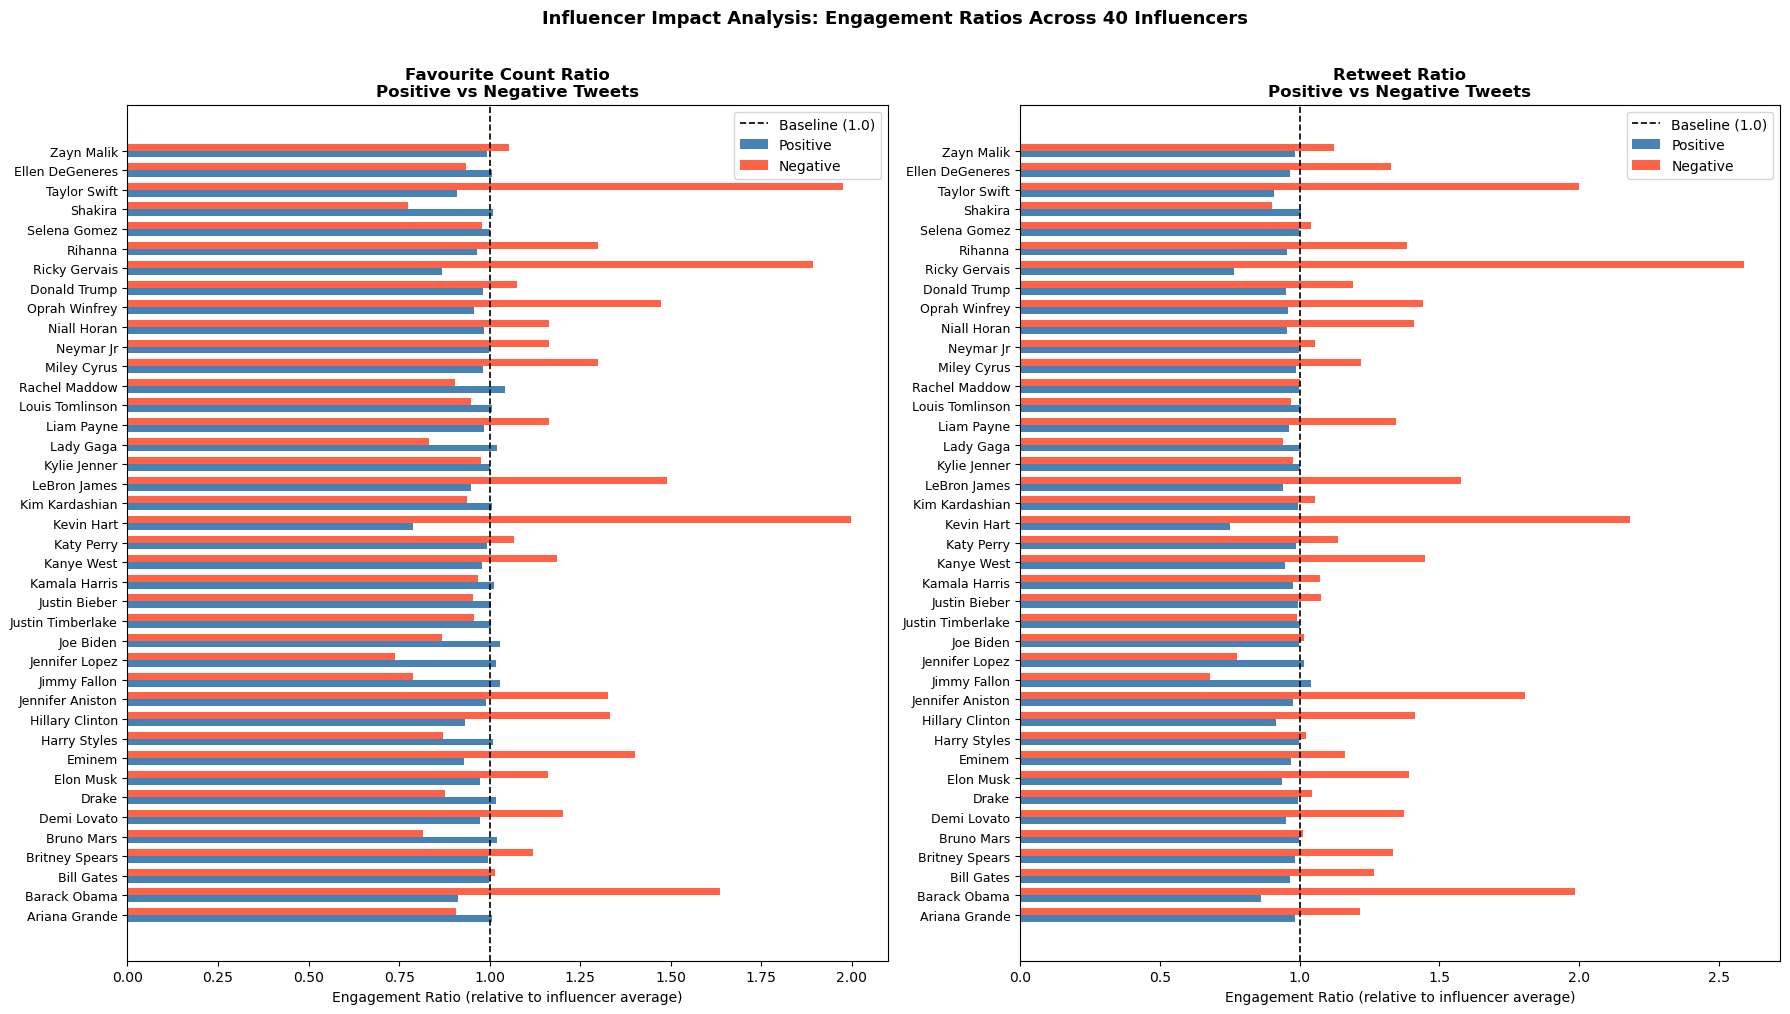

In [101]:
# ============================================================
# VISUALISATIONS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Load the output data
output = pd.read_csv('Output.csv', header=None, names=[
    'Celeb', 'fc_avg', 'rt_avg', 'p_fc_avg', 'p_rt_avg',
    'n_fc_avg', 'n_rt_avg', 'p_fc_ratio', 'p_rt_ratio',
    'n_fc_ratio', 'n_rt_ratio'
])
print(output.shape)
print(output.head(3))

# ============================================================
# Chart 1: Positive vs Negative Engagement Ratios per Influencer
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

influencers = output['Celeb']
x = np.arange(len(influencers))
bar_width = 0.35

# Favourite Count Ratios
axes[0].barh(x - bar_width/2, output['p_fc_ratio'], bar_width,
             color='steelblue', label='Positive')
axes[0].barh(x + bar_width/2, output['n_fc_ratio'], bar_width,
             color='tomato', label='Negative')
axes[0].axvline(x=1.0, color='black', linestyle='--', linewidth=1.2, label='Baseline (1.0)')
axes[0].set_yticks(x)
axes[0].set_yticklabels(influencers, fontsize=9)
axes[0].set_xlabel('Engagement Ratio (relative to influencer average)')
axes[0].set_title('Favourite Count Ratio\nPositive vs Negative Tweets', fontweight='bold')
axes[0].legend()

# Retweet Ratios
axes[1].barh(x - bar_width/2, output['p_rt_ratio'], bar_width,
             color='steelblue', label='Positive')
axes[1].barh(x + bar_width/2, output['n_rt_ratio'], bar_width,
             color='tomato', label='Negative')
axes[1].axvline(x=1.0, color='black', linestyle='--', linewidth=1.2, label='Baseline (1.0)')
axes[1].set_yticks(x)
axes[1].set_yticklabels(influencers, fontsize=9)
axes[1].set_xlabel('Engagement Ratio (relative to influencer average)')
axes[1].set_title('Retweet Ratio\nPositive vs Negative Tweets', fontweight='bold')
axes[1].legend()

plt.suptitle('Influencer Impact Analysis: Engagement Ratios Across 40 Influencers',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart1_engagement_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

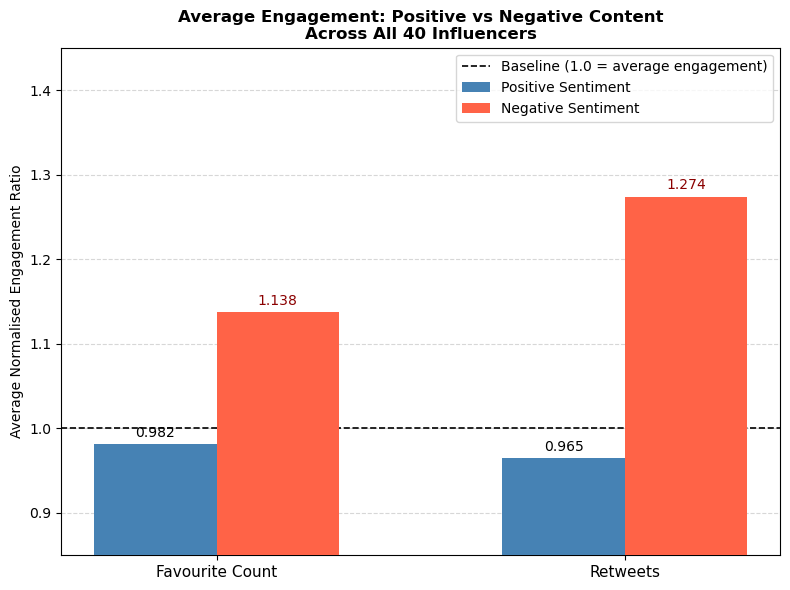

In [102]:
# ============================================================
# Chart 2: Overall Summary - Average Ratios (Key Finding)
# ============================================================

categories = ['Favourite Count', 'Retweets']
positive_means = [output['p_fc_ratio'].mean(), output['p_rt_ratio'].mean()]
negative_means = [output['n_fc_ratio'].mean(), output['n_rt_ratio'].mean()]

x = np.arange(len(categories))
bar_width = 0.3

fig, ax = plt.subplots(figsize=(8, 6))

bars_pos = ax.bar(x - bar_width/2, positive_means, bar_width,
                  color='steelblue', label='Positive Sentiment', zorder=3)
bars_neg = ax.bar(x + bar_width/2, negative_means, bar_width,
                  color='tomato', label='Negative Sentiment', zorder=3)

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.2,
           label='Baseline (1.0 = average engagement)')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('Average Normalised Engagement Ratio')
ax.set_title('Average Engagement: Positive vs Negative Content\nAcross All 40 Influencers',
             fontweight='bold')
ax.set_ylim(0.85, 1.45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

# Add value labels on bars
for bar in bars_pos:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars_neg:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, color='darkred')

plt.tight_layout()
plt.savefig('chart2_summary.png', dpi=150, bbox_inches='tight')
plt.show()

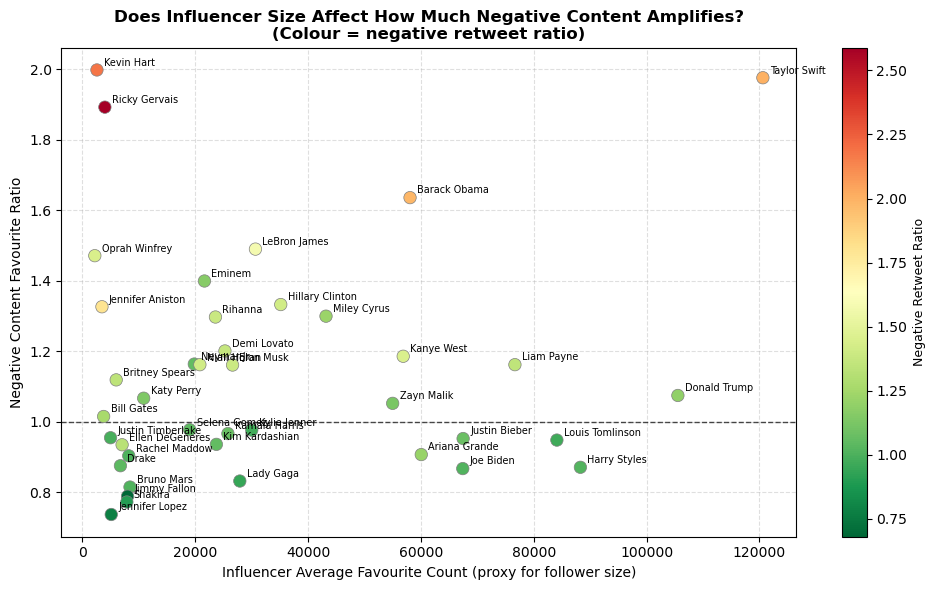

In [103]:
# ============================================================
# Chart 3: Scatter Plot - Does follower size affect the pattern?
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(output['fc_avg'], output['n_fc_ratio'],
                     c=output['n_rt_ratio'], cmap='RdYlGn_r',
                     s=80, edgecolors='grey', linewidths=0.5, zorder=3)

for i, row in output.iterrows():
    ax.annotate(row['Celeb'], (row['fc_avg'], row['n_fc_ratio']),
                textcoords='offset points', xytext=(5, 3), fontsize=7)

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Influencer Average Favourite Count (proxy for follower size)', fontsize=10)
ax.set_ylabel('Negative Content Favourite Ratio', fontsize=10)
ax.set_title('Does Influencer Size Affect How Much Negative Content Amplifies?\n(Colour = negative retweet ratio)',
             fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Negative Retweet Ratio', fontsize=9)
ax.grid(linestyle='--', alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig('chart3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()